# Titanic — Análise Exploratória de Dados (EDA)
> **Autor:** Breno Silva Barros Rangel
> **Data:** 03/2026
> **Dataset:** [Titanic - Machine Learning from Disaster](https://www.kaggle.com/c/titanic)

---

## Sobre este notebook

Este notebook apresenta uma análise exploratória completa do famoso dataset do **Titanic**.

O naufrágio do Titanic em 1912 é um dos acidentes marítimos mais conhecidos da história. Nesta análise, vamos investigar:

- Quem eram os passageiros?
- Quais fatores influenciaram a sobrevivência?
- O que os dados nos contam sobre desigualdade e prioridade no resgate?

---

## Índice
1. [Importação de Bibliotecas](#1)
2. [Carregamento dos Dados](#2)
3. [Visão Geral do Dataset](#3)
4. [Limpeza dos Dados](#4)
5. [Análise Univariada](#5)
6. [Análise Bivariada](#6)
7. [Análise de Correlação](#7)
8. [Conclusões e Insights](#8)

---
## 1. Importação de Bibliotecas <a id='1'></a>

In [1]:
# Manipulação de dados
import pandas as pd
import numpy as np

# Visualização
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

# Configurações visuais
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

# Suprimir avisos desnecessários
import warnings
warnings.filterwarnings('ignore')

print('Bibliotecas importadas com sucesso!')

Bibliotecas importadas com sucesso!


---
## 2. Carregamento dos Dados <a id='2'></a>

In [2]:
# Carregando o dataset de treino
df = pd.read_csv('/kaggle/input/competitions/titanic/train.csv')
print(f'✅ Dataset carregado com sucesso!')
print(f'📐 Dimensões: {df.shape[0]} linhas x {df.shape[1]} colunas')

✅ Dataset carregado com sucesso!
📐 Dimensões: 891 linhas x 12 colunas


---
## 3. Visão Geral do Dataset <a id='3'></a>

Antes de qualquer análise, é fundamental entender **o que cada coluna representa**:

| Coluna | Descrição |
|---|---|
| `PassengerId` | ID único do passageiro |
| `Survived` | 0 = Não sobreviveu, 1 = Sobreviveu |
| `Pclass` | Classe do bilhete (1 = 1ª, 2 = 2ª, 3 = 3ª) |
| `Name` | Nome do passageiro |
| `Sex` | Sexo |
| `Age` | Idade |
| `SibSp` | Nº de irmãos/cônjuges a bordo |
| `Parch` | Nº de pais/filhos a bordo |
| `Ticket` | Número do bilhete |
| `Fare` | Tarifa paga |
| `Cabin` | Número da cabine |
| `Embarked` | Porto de embarque (C = Cherbourg, Q = Queenstown, S = Southampton) |

In [3]:
# Primeiras linhas do dataset
print('Primeiras 5 linhas:')
df.head()

Primeiras 5 linhas:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
# Tipos de dados e valores não nulos
print('Informações do dataset:')
df.info()

Informações do dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [5]:
# Estatísticas descritivas
print('Estatísticas descritivas:')
df.describe().round(2)

Estatísticas descritivas:


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.00,891.00,891.00,714.00,891.00,891.00,891.00
mean,446.00,0.38,2.31,29.70,0.52,0.38,32.20
std,257.35,0.49,0.84,14.53,1.10,0.81,49.69
min,1.00,0.00,1.00,0.42,0.00,0.00,0.00
25%,223.50,0.00,2.00,20.12,0.00,0.00,7.91
50%,446.00,0.00,3.00,28.00,0.00,0.00,14.45
75%,668.50,1.00,3.00,38.00,1.00,0.00,31.00
max,891.00,1.00,3.00,80.00,8.00,6.00,512.33


---
## 4. Limpeza dos Dados <a id='4'></a>

Vamos identificar e tratar valores ausentes antes de prosseguir com a análise.

In [6]:
# Verificando valores nulos
nulos = df.isnull().sum()
nulos_pct = (df.isnull().sum() / len(df) * 100).round(2)

resumo_nulos = pd.DataFrame({
    'Valores Nulos': nulos,
    'Percentual (%)': nulos_pct
}).query('`Valores Nulos` > 0').sort_values('Percentual (%)', ascending=False)

print('Colunas com valores ausentes:')
print(resumo_nulos)

Colunas com valores ausentes:
          Valores Nulos  Percentual (%)
Cabin               687           77.10
Age                 177           19.87
Embarked              2            0.22


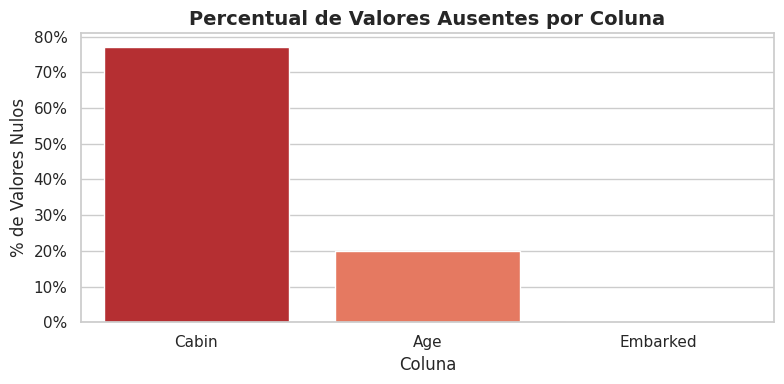

In [7]:
# Visualizando valores nulos
fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(
    x=resumo_nulos.index,
    y=resumo_nulos['Percentual (%)'],
    palette='Reds_r',
    ax=ax
)
ax.set_title('Percentual de Valores Ausentes por Coluna', fontsize=14, fontweight='bold')
ax.set_ylabel('% de Valores Nulos')
ax.set_xlabel('Coluna')
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
plt.tight_layout()
plt.show()

In [8]:
# Tratamento dos valores ausentes
df_clean = df.copy()

# Age: preencher com a mediana (mais robusta que a média)
df_clean['Age'].fillna(df_clean['Age'].median(), inplace=True)

# Embarked: preencher com o valor mais frequente
df_clean['Embarked'].fillna(df_clean['Embarked'].mode()[0], inplace=True)

# Cabin: muitos nulos (77%) — vamos criar uma flag se tem ou não cabine
df_clean['Has_Cabin'] = df_clean['Cabin'].notna().astype(int)
df_clean.drop(columns=['Cabin'], inplace=True)

print(f'Limpeza concluída!')
print(f'Valores nulos restantes: {df_clean.isnull().sum().sum()}')

Limpeza concluída!
Valores nulos restantes: 0


---
## 5. Análise Univariada <a id='5'></a>

Vamos analisar cada variável individualmente para entender sua distribuição.

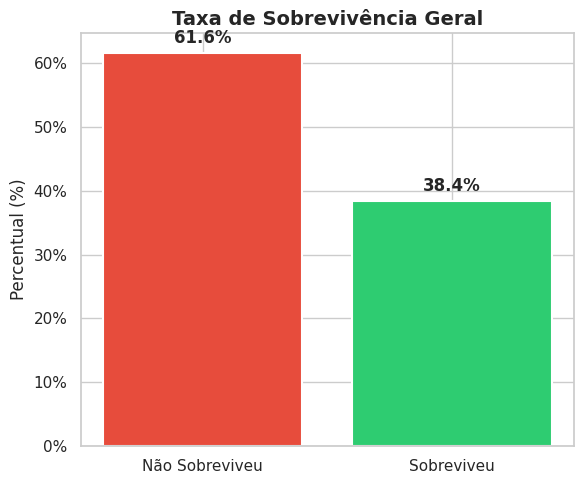


38.4% dos passageiros sobreviveram.


In [9]:
# Taxa geral de sobrevivência
sobreviventes = df_clean['Survived'].value_counts(normalize=True) * 100

fig, ax = plt.subplots(figsize=(6, 5))
bars = ax.bar(
    ['Não Sobreviveu', 'Sobreviveu'],
    sobreviventes.values,
    color=['#e74c3c', '#2ecc71'],
    edgecolor='white',
    linewidth=1.5
)
ax.set_title('Taxa de Sobrevivência Geral', fontsize=14, fontweight='bold')
ax.set_ylabel('Percentual (%)')
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
for bar, val in zip(bars, sobreviventes.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{val:.1f}%', ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.show()

print(f'\n{sobreviventes[1]:.1f}% dos passageiros sobreviveram.')

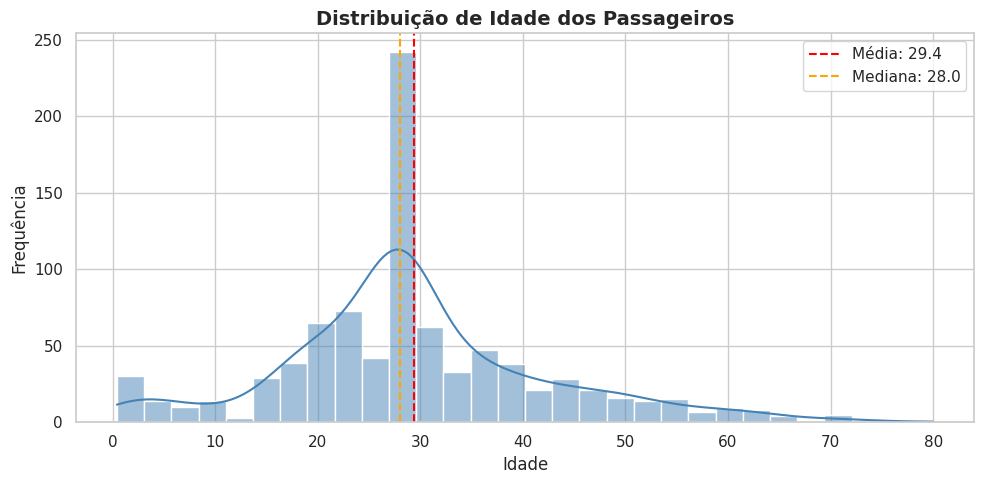

In [10]:
# Distribuição de idade
fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(df_clean['Age'], bins=30, kde=True, color='steelblue', ax=ax)
ax.axvline(df_clean['Age'].mean(), color='red', linestyle='--', label=f'Média: {df_clean["Age"].mean():.1f}')
ax.axvline(df_clean['Age'].median(), color='orange', linestyle='--', label=f'Mediana: {df_clean["Age"].median():.1f}')
ax.set_title('Distribuição de Idade dos Passageiros', fontsize=14, fontweight='bold')
ax.set_xlabel('Idade')
ax.set_ylabel('Frequência')
ax.legend()
plt.tight_layout()
plt.show()

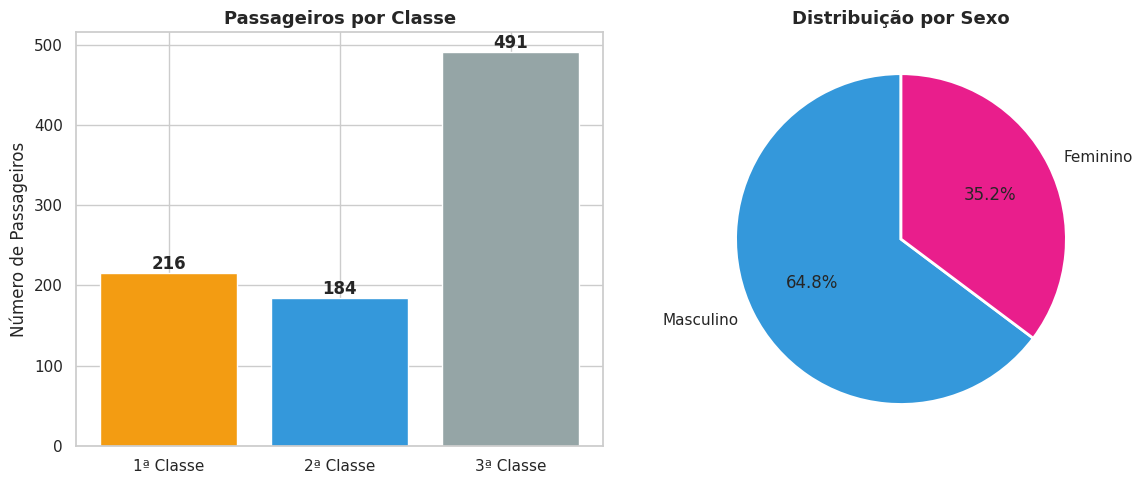

In [11]:
# Classe e sexo dos passageiros
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Classe
classe_counts = df_clean['Pclass'].value_counts().sort_index()
axes[0].bar(
    ['1ª Classe', '2ª Classe', '3ª Classe'],
    classe_counts.values,
    color=['#f39c12', '#3498db', '#95a5a6'],
    edgecolor='white'
)
axes[0].set_title('Passageiros por Classe', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Número de Passageiros')
for i, v in enumerate(classe_counts.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

# Sexo
sexo_counts = df_clean['Sex'].value_counts()
axes[1].pie(
    sexo_counts.values,
    labels=['Masculino', 'Feminino'],
    autopct='%1.1f%%',
    colors=['#3498db', '#e91e8c'],
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
axes[1].set_title('Distribuição por Sexo', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

---
## 6. Análise Bivariada <a id='6'></a>

Agora vamos cruzar as variáveis com a sobrevivência para encontrar **padrões e insights**.

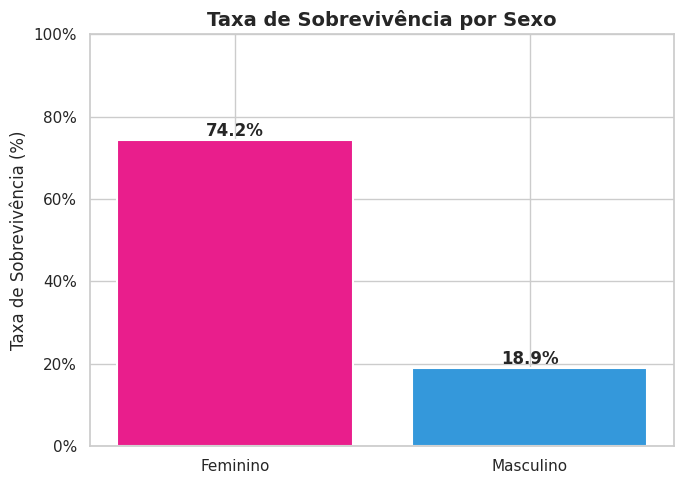


Mulheres tinham 74.2% de taxa de sobrevivência
Homens tinham 18.9% de taxa de sobrevivência


In [12]:
# Sobrevivência por Sexo
sobrev_sexo = df_clean.groupby('Sex')['Survived'].mean() * 100

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(
    ['Feminino', 'Masculino'],
    [sobrev_sexo['female'], sobrev_sexo['male']],
    color=['#e91e8c', '#3498db'],
    edgecolor='white',
    linewidth=1.5
)
ax.set_title('Taxa de Sobrevivência por Sexo', fontsize=14, fontweight='bold')
ax.set_ylabel('Taxa de Sobrevivência (%)')
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_ylim(0, 100)
for bar, val in zip(bars, [sobrev_sexo['female'], sobrev_sexo['male']]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{val:.1f}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

print(f'\nMulheres tinham {sobrev_sexo["female"]:.1f}% de taxa de sobrevivência')
print(f'Homens tinham {sobrev_sexo["male"]:.1f}% de taxa de sobrevivência')

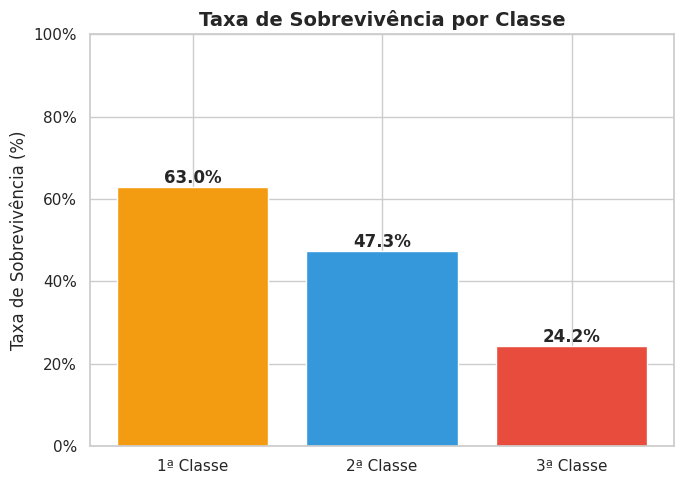

In [13]:
# Sobrevivência por Classe
sobrev_classe = df_clean.groupby('Pclass')['Survived'].mean() * 100

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(
    ['1ª Classe', '2ª Classe', '3ª Classe'],
    sobrev_classe.values,
    color=['#f39c12', '#3498db', '#e74c3c'],
    edgecolor='white'
)
ax.set_title('Taxa de Sobrevivência por Classe', fontsize=14, fontweight='bold')
ax.set_ylabel('Taxa de Sobrevivência (%)')
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_ylim(0, 100)
for bar, val in zip(bars, sobrev_classe.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{val:.1f}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

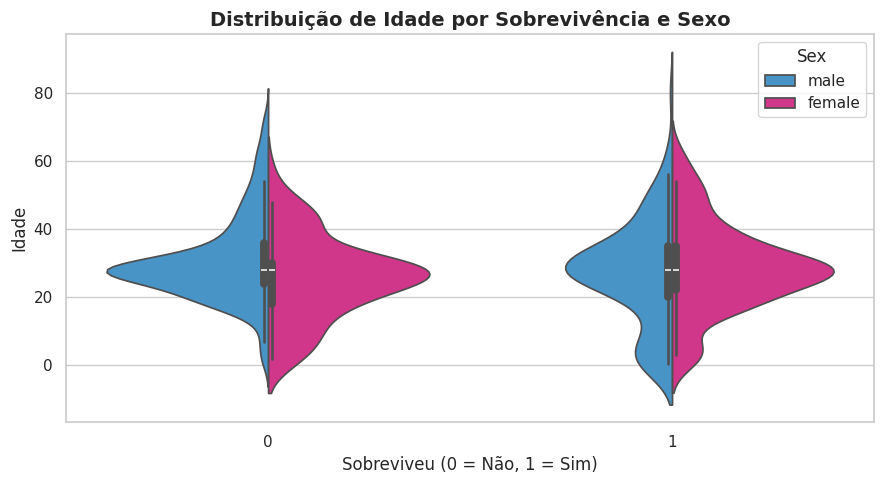

In [14]:
# Distribuição de idade por sobrevivência
fig, ax = plt.subplots(figsize=(9, 5))
sns.violinplot(
    data=df_clean,
    x='Survived',
    y='Age',
    hue='Sex',
    split=True,
    palette={'male': '#3498db', 'female': '#e91e8c'},
    ax=ax
)
ax.set_title('Distribuição de Idade por Sobrevivência e Sexo', fontsize=14, fontweight='bold')
ax.set_xlabel('Sobreviveu (0 = Não, 1 = Sim)')
ax.set_ylabel('Idade')
plt.tight_layout()
plt.show()

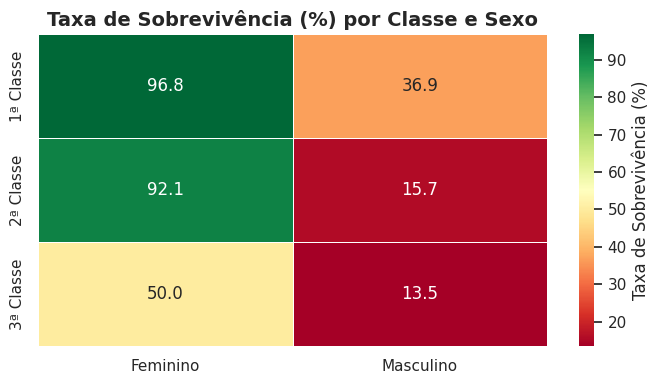

In [15]:
# Heatmap: Sobrevivência por Classe e Sexo
pivot = df_clean.pivot_table(
    values='Survived',
    index='Pclass',
    columns='Sex',
    aggfunc='mean'
) * 100

pivot.index = ['1ª Classe', '2ª Classe', '3ª Classe']
pivot.columns = ['Feminino', 'Masculino']

fig, ax = plt.subplots(figsize=(7, 4))
sns.heatmap(
    pivot,
    annot=True,
    fmt='.1f',
    cmap='RdYlGn',
    linewidths=0.5,
    ax=ax,
    cbar_kws={'label': 'Taxa de Sobrevivência (%)'}
)
ax.set_title('Taxa de Sobrevivência (%) por Classe e Sexo', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 7. Análise de Correlação <a id='7'></a>

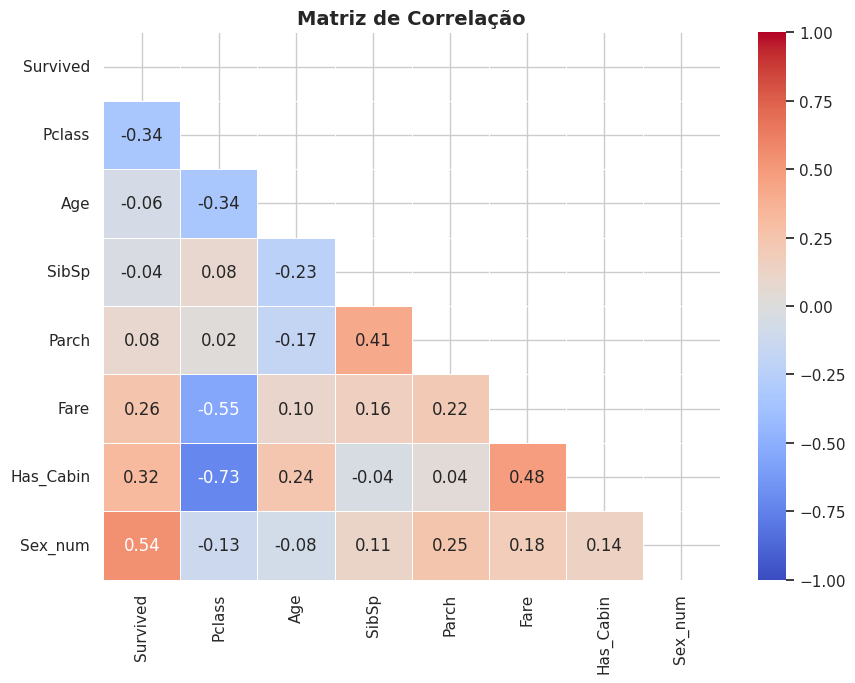

In [16]:
# Preparando dados numéricos
df_corr = df_clean.copy()
df_corr['Sex_num'] = (df_corr['Sex'] == 'female').astype(int)

colunas_num = ['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Has_Cabin', 'Sex_num']
corr_matrix = df_corr[colunas_num].corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    mask=mask,
    linewidths=0.5,
    ax=ax,
    vmin=-1, vmax=1
)
ax.set_title('Matriz de Correlação', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 8. Conclusões e Insights <a id='8'></a>

Após toda a análise, chegamos às seguintes conclusões:

### Principais Insights

| # | Insight | Evidência |
|---|---|---|
| 1 | **Sexo foi o fator mais determinante** | Mulheres sobreviveram ~74% vs ~19% dos homens |
| 2 | **Classe social impactou diretamente** | 1ª classe: ~63% de sobrevivência vs ~24% na 3ª |
| 3 | **Crianças tinham mais prioridade** | Passageiros mais jovens tiveram maior sobrevivência |
| 4 | **Ter cabine = maior chance** | Passageiros com cabine eram da 1ª/2ª classe e sobreviveram mais |
| 5 | **A regra era: mulheres e crianças primeiro** | Os dados confirmam essa prioridade no resgate |

### Reflexão Final

> O Titanic não foi apenas um acidente, foi um espelho da sociedade de 1912. 
> Os dados mostram claramente que **classe social e gênero determinaram quem viveu e quem morreu**.
> Isso vai além dos números: é uma história humana contada através dos dados.

---

### Próximos Passos

- [ ] Criar features novas (feature engineering)
- [ ] Treinar um modelo de classificação (Logistic Regression, Random Forest)
- [ ] Submeter previsões na competição do Kaggle

---

**Se este notebook foi útil para você, deixe um upvote! Comentários e sugestões são bem-vindos. 😊**